# Energy Poverty Identification (Balanced Feature Importance)
**SDG Goal: SDG 1 – No Poverty**

This notebook classifies rural households into **Energy Secure** or **Energy Impoverished**.
A weighted multi‑factor definition is used, and **Random Forest** is applied for feature importance
so that multiple variables contribute to the model.


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

## 2. Load Dataset

In [2]:
df = pd.read_csv("Cleaned_dataset_energy_poverty.csv")
df.head()

,hh,sex,age,lga,edu,mrt_status,fmly_size,m_income,cfuel,ipollut,...,illiness,waterborne,resp_disease,eye_disease,child_death,maternalcare,square_meal,health_ins,rooms_per_person,people_per_room
0,1.0,1,3.0,1,6,1,4,4,6,1,...,2.0,0,0.0,0,0,2.0,3.0,1.0,0.400000,1.333333
1,2.0,1,3.0,1,7,1,7,7,6,1,...,5.0,2,0.0,0,0,2.0,3.0,1.0,0.375000,1.750000
2,3.0,1,3.0,1,6,1,5,5,6,1,...,2.0,0,0.0,0,0,2.0,3.0,1.0,0.666667,1.000000
3,4.0,1,3.0,1,6,1,6,3,6,1,...,4.0,0,0.0,0,2,2.0,2.0,1.0,0.571429,1.200000
4,5.0,1,4.0,1,5,1,10,7,6,1,...,10.0,2,0.0,0,0,1.0,3.0,1.0,0.454545,1.666667


## 3. Dataset Overview

In [3]:
print("Dataset Shape:", df.shape)
df.info()
df.describe()

Dataset Shape: (499, 54)
<class 'pandas.DataFrame'>
RangeIndex: 499 entries, 0 to 498
Data columns (total 54 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   hh                499 non-null    float64
 1   sex               499 non-null    int64  
 2   age               499 non-null    float64
 3   lga               499 non-null    int64  
 4   edu               499 non-null    int64  
 5   mrt_status        499 non-null    int64  
 6   fmly_size         499 non-null    int64  
 7   m_income          499 non-null    int64  
 8   cfuel             499 non-null    int64  
 9   ipollut           499 non-null    int64  
 10  rbiomass          499 non-null    float64
 11  dailycook         499 non-null    float64
 12  avl_lpg           499 non-null    int64  
 13  aff_lpg           499 non-null    int64  
 14  Electricity       499 non-null    float64
 15  hrs_elect         499 non-null    float64
 16  aff_elct          499 non-null

,hh,sex,age,lga,edu,mrt_status,fmly_size,m_income,cfuel,ipollut,...,illiness,waterborne,resp_disease,eye_disease,child_death,maternalcare,square_meal,health_ins,rooms_per_person,people_per_room
count,499.000000,499.000000,499.000000,499.000000,499.000000,499.000000,499.000000,499.000000,499.000000,499.000000,...,499.000000,499.000000,499.000000,499.000000,499.000000,499.000000,499.000000,499.000000,499.000000,499.000000
mean,84.020040,1.036072,3.517034,3.468938,3.416834,1.472946,8.665331,2.869739,3.649299,1.404810,...,3.595190,2.068136,0.440882,0.661323,1.354709,1.438878,2.829659,1.629259,0.536222,1.821303
std,27.876946,0.186657,1.234222,1.868288,1.604023,1.062679,5.501572,1.734676,1.429485,0.491348,...,2.575849,2.366807,1.193192,1.313938,1.707658,0.496748,0.508010,0.483488,0.375313,1.196023
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.062500,0.181818
25%,84.000000,1.000000,3.000000,2.000000,2.000000,1.000000,5.000000,2.000000,3.000000,1.000000,...,2.000000,0.000000,0.000000,0.000000,0.000000,1.000000,3.000000,1.000000,0.285714,1.000000
50%,84.000000,1.000000,3.000000,4.000000,3.000000,1.000000,7.000000,2.000000,3.000000,1.000000,...,3.000000,1.000000,0.000000,0.000000,1.000000,1.000000,3.000000,2.000000,0.437500,1.600000
75%,84.000000,1.000000,4.000000,5.000000,5.000000,1.000000,11.000000,4.000000,4.000000,2.000000,...,5.000000,3.000000,0.000000,1.000000,2.000000,2.000000,3.000000,2.000000,0.666667,2.333333
max,167.000000,2.000000,6.000000,6.000000,7.000000,4.000000,40.000000,7.000000,7.000000,2.000000,...,15.000000,15.000000,10.000000,12.000000,15.000000,2.000000,6.000000,2.000000,3.333333,10.000000


## 4. Create Weighted Energy Poverty Target

In [4]:
df["energy_score"] = (
    (df["Electricity"] == 0) * 3 +
    (df["hrs_elect"] < 8) * 2 +
    (df["cfuel"] == 1) * 2 +
    (df["avl_lpg"] == 0) * 1 +
    (df["ipollut"] == 1) * 1
)

df["Energy_Poverty"] = (df["energy_score"] >= 3).astype(int)

df[["energy_score","Energy_Poverty"]].head()

,energy_score,Energy_Poverty
0,1,0
1,1,0
2,3,1
3,1,0
4,3,1


## 5. Remove ID Column

In [5]:
if "hh" in df.columns:
    df = df.drop("hh", axis=1)

## 6. Define Features and Target

In [6]:
X = df.drop(["Energy_Poverty", "energy_score", "Electricity", "hrs_elect", "cfuel", "avl_lpg", "ipollut"], axis=1)
y = df["Energy_Poverty"]

## 7. Train-Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [8]:
# 7.1 Scale Features (Crucial for SVM and Logistic Regression)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 8. Train Multiple Models

In [9]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "Decision Tree": DecisionTreeClassifier(max_depth=5),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42),
    "SVM": SVC(),
    "Gradient Boosting": GradientBoostingClassifier()
}

results = []

for name, model in models.items():
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    print("\n====================")
    print("Model:", name)
    print("Accuracy:", acc)

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print(classification_report(y_test, y_pred))

    results.append((name, acc))



Model: Logistic Regression
Accuracy: 0.5933333333333334
Confusion Matrix:
[[33 30]
 [31 56]]
              precision    recall  f1-score   support

           0       0.52      0.52      0.52        63
           1       0.65      0.64      0.65        87

    accuracy                           0.59       150
   macro avg       0.58      0.58      0.58       150
weighted avg       0.59      0.59      0.59       150


Model: Decision Tree
Accuracy: 0.54
Confusion Matrix:
[[40 23]
 [46 41]]
              precision    recall  f1-score   support

           0       0.47      0.63      0.54        63
           1       0.64      0.47      0.54        87

    accuracy                           0.54       150
   macro avg       0.55      0.55      0.54       150
weighted avg       0.57      0.54      0.54       150


Model: Random Forest
Accuracy: 0.6466666666666666
Confusion Matrix:
[[34 29]
 [24 63]]
              precision    recall  f1-score   support

           0       0.59      0.54  

## 9. Find Best Model

In [10]:
best_model = sorted(results, key=lambda x: x[1], reverse=True)[0]
print("Best Model:", best_model[0])
print("Best Accuracy:", best_model[1])


Best Model: SVM
Best Accuracy: 0.6933333333333334


## 10. Train Random Forest for Feature Importance

In [11]:
rf_model = RandomForestClassifier(n_estimators=300, max_depth=6, random_state=42)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

## 11. Confusion Matrix

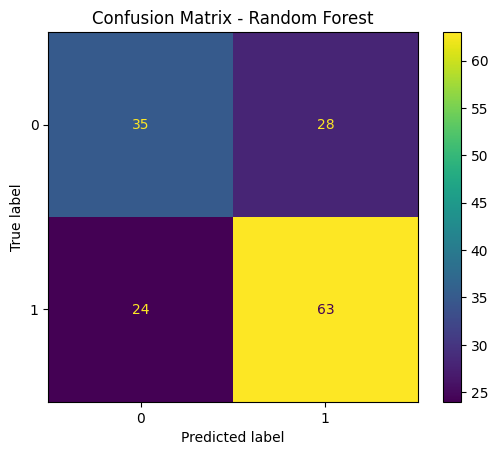

In [12]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix - Random Forest")
plt.show()

## 12. Feature Importance

In [13]:
importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

feature_importance.head(15)

,Feature,Importance
19,occupation,0.071617
5,fmly_size,0.055040
14,exp_nonlpg,0.054261
33,sch_days,0.048229
24,rooms,0.043711
47,people_per_room,0.041526
20,hh_exp,0.040378
46,rooms_per_person,0.039744
2,lga,0.037439
39,waterborne,0.034338


## 13. Plot Feature Importance

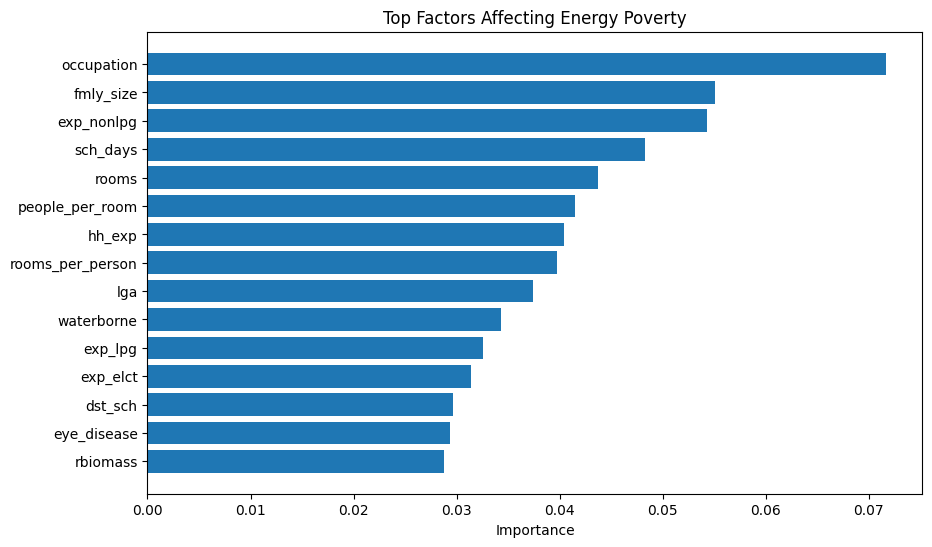

In [14]:
plt.figure(figsize=(10,6))

plt.barh(feature_importance["Feature"][:15],
         feature_importance["Importance"][:15])

plt.gca().invert_yaxis()

plt.title("Top Factors Affecting Energy Poverty")

plt.xlabel("Importance")

plt.show()

## Conclusion

Energy poverty was defined using multiple weighted indicators including electricity access,
electricity availability, cooking fuel type, LPG availability, and indoor pollution.

Random Forest was used for feature importance because it distributes importance across
multiple variables and provides more stable insights into the factors affecting energy poverty.
